## Territorial Patterns of Mining Extraction Methods in Peru

### By mineral type, production scale, and development status

---

**Competition:** Codedex Data Science Challenge  
**Author:**  LuiccianDev 
**Date:** February 26, 2026  
**Dataset:** `df_peru_cleaned.csv` — 3,057 records of mining sites in Peru


--- 

### About the Data

- **Original source:** The dataset was extracted from [Kaggle — Mineral Ores Around the World](https://www.kaggle.com/datasets/ramjasmaurya/mineral-ores-around-the-world/data), which compiles information from the **USGS Mineral Resources Data System (MRDS)**.
- **Scope:** Only records corresponding to **Peru** were filtered, resulting in **3,055 registered mining sites**.
- **Nature of the data:** The MRDS is a geological-mining inventory, not a production registry. It includes everything from large active mines to simple mineral occurrences without development. This explains why a significant proportion of records have no defined extraction method — **it is not a data error**, but rather a reflection that many sites are prospects or occurrences in early stages.

---

### Main Question

 **What extraction method dominates in Peru by mineral type and region, and how does it relate to production scale and project development status?**

---

### Table of Contents

1. **Phase 0** — Setup and data loading
2. **Phase 1** — Exploration and cleaning
3. **Block 1** — National diagnosis of extraction method
4. **Block 2** — Method–mineral relationship
5. **Block 3** — Territorial distribution (regional)
6. **Block 4** — Method and production scale
7. **Block 5** — Method and project maturity
8. **Discussion and Conclusions**

---

### Key Analysis Variables

| Variable | Role in the analysis |
|----------|-------------------|
| `work_type` | Dependent variable — Extraction method |
| `commod1` | Primary mineral type |
| `state` | Region / department |
| `prod_size` | Production scale |
| `dev_stat` | Project development status |
| `latitude`, `longitude` | Geolocation for maps |

---

## Context: Peru as a Global Mining Powerhouse

Before diving into the analysis, it is essential to understand **why Peru is such a relevant case study** in global mining and to familiarize ourselves with the technical concepts we will use throughout this notebook.

---

### Peru in the World Mining Rankings

Peru is one of the leading mining powerhouses on the planet. According to data from the **U.S. Geological Survey (USGS)** and the **Ministry of Energy and Mines (MINEM)**, the country holds world leadership positions in the production of multiple minerals:

| Mineral | World Ranking | Latin America Ranking |
|---------|:--------------:|:------------------------:|
| **Copper (Cu)** | 2nd world producer | 2nd (after Chile) |
| **Silver (Ag)** | 2nd world producer | 1st in the region |
| **Zinc (Zn)** | 2nd world producer | 1st in the region |
| **Lead (Pb)** | 3rd world producer | 1st in the region |
| **Tin (Sn)** | 4th world producer | 1st in the region |
| **Molybdenum (Mo)** | 4th world producer | 2nd (after Chile) |
| **Gold (Au)** | Top 10 world producer | 1st in the region |

**Key facts about the Peruvian mining industry:**
- Mining represents approximately **50% of Peru's total exports** and has been a central engine of economic growth for decades.
- The mining sector has attracted more than **$60 billion USD** in projected investment for the next decade.
- Major operations include: **Antamina** (Cu, Zn — Áncash), **Cerro Verde** (Cu — Arequipa), **Las Bambas** (Cu — Apurímac), **Yanacocha** (Au — Cajamarca), **Volcan** (Zn, Pb — Junín/Pasco), among others.



---

### Geology: The Metallogenic Belts of the Peruvian Andes

The **Andes Mountain Range**, which runs through Peru from north to south, defines **metallogenic belts** — geological zones with specific mineral concentrations formed by tectonic and magmatic processes over millions of years. These belts are the reason why certain minerals and extraction methods are concentrated in specific regions of the country.

| Metallogenic Belt | Location | Main Minerals | Deposit Type | Typical Method |
|---------------------|-----------|----------------------|------------------|---------------|
| **Central Polymetallic Belt** | Junín, Pasco, Ancash, Lima, Huancavelica | Zinc, Lead, Silver, Copper | Veins and replacement bodies | Underground |
| **Copper Corridor (Southern Andes)** | Arequipa, Cusco, Apurímac, Tacna, Moquegua | Copper, Molybdenum, Gold | Porphyry and disseminated deposits | Surface (open pit) |
| **Northern Gold Belt** | Cajamarca, La Libertad, Ayacucho | Gold, Silver | Epithermal veins and disseminated deposits | Underground and Surface |
| **Southern Polymetallic Belt** | Puno, Cusco | Tin, Silver, Zinc | Veins and placers | Underground |

**Why does this matter for the analysis?**
Understanding these belts helps explain the patterns we will find in **Block 3** (territorial distribution): it is no coincidence that certain regions have a higher proportion of underground or open-pit mining — it is determined by the geology of the subsoil.

---

### Mining Extraction Methods: Key Concepts

The **extraction method** (`work_type` in our dataset) is the central variable of this analysis. There are three main methods:

#### 1. Underground (Subsurface Mining)
- **Description:** The ore body is accessed through **tunnels, galleries, and shafts** excavated beneath the surface.
- **When used:** When the mineral is found in **vein-type deposits** — narrow, deep bodies with high ore grade (mineral concentration).
- **Typical minerals:** Gold (Au), Silver (Ag), Zinc (Zn), Lead (Pb).
- **Characteristics:** Less surface disturbance, greater extraction selectivity, relatively smaller-scale operation. Requires ventilation, drainage, and ground support infrastructure.
- **Example in Peru:** San Rafael Mine (tin, Puno), Volcan mines (zinc-lead, Junín).

#### 2. Surface (Open Pit Mining)
- **Description:** Large volumes of rock and soil are removed from the surface to access the mineral. An **open pit** is excavated that can span several kilometers in diameter.
- **When used:** When the mineral is found in **porphyry or disseminated deposits** — broad, shallow bodies (close to the surface) with lower ore grade.
- **Typical minerals:** Copper (Cu), Molybdenum (Mo), Gold (in disseminated deposits).
- **Characteristics:** Requires high capital investment, large processing volumes (economies of scale), greater surface environmental impact.
- **Example in Peru:** Cerro Verde (copper, Arequipa), Antamina (copper-zinc, Áncash), Las Bambas (copper, Apurímac).

#### 3. Surface/Underground (Mixed Operation)
- **Description:** Operations that **combine both methods** depending on the depth, geometry, and ore grade of the deposit.
- **When used:** When a single deposit has shallower zones (exploitable via open pit) and deeper zones (requiring underground access), or when an operation transitions from surface to underground as it deepens.
- **Example in Peru:** Some operations in Cerro de Pasco combine open pit and underground galleries.

---

In [1]:
# PHASE 0 — Environment setup

# Data manipulation libraries
import pandas as pd
import numpy as np
# Static visualization libraries
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import json

# Interactive visualization libraries (maps)
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
# Global legend
from matplotlib.patches import Patch
# Global style configuration
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update(
    {
        "figure.figsize": (12, 6),
        "figure.dpi": 100,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "font.family": "sans-serif",
    }
)

# Consistent color palette for extraction methods
METHOD_COLORS = {
    "Underground": "#2196F3",
    "Surface": "#FF9800",
    "Surface/Underground": "#9C27B0",
    "Unknown": "#E0E0E0",
}
METHOD_ORDER = ["Underground", "Surface", "Surface/Underground", "Unknown"]

# Palette for production scales
SIZE_COLORS = {
    "Grande": "#E53935",
    "Mediano": "#FB8C00",
    "Pequeño": "#43A047",
    "Sin dato": "#BDBDBD",
    "Desconocido": "#E0E0E0",
}

print("Modules loaded and environment configured successfully")

Modules loaded and environment configured successfully


In [2]:
# Load dataset

df = pd.read_csv("../Data/df_peru_cleaned.csv")

print(f"Dataset loaded: {df.shape[0]} records × {df.shape[1]} columns")
print("Available columns:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:2d}. {col}")

df.head()  # Data preview

Dataset loaded: 3055 records × 13 columns
Available columns:
    1. site_name
    2. latitude
    3. longitude
    4. state
    5. com_type
    6. commod1
    7. dep_type
    8. prod_size
    9. dev_stat
   10. ore
   11. work_type
   12. hrock_type
   13. arock_type


,site_name,latitude,longitude,state,com_type,commod1,dep_type,prod_size,dev_stat,ore,work_type,hrock_type,arock_type
0,Concesion,-3.62490,-77.80310,Amazonas,M,Gold,NaN,U,Occurrence,NaN,NaN,NaN,NaN
1,"Tamborapa, Consecion",-5.37621,-78.73312,Amazonas,M,Gold,NaN,U,Occurrence,NaN,NaN,NaN,NaN
2,"Chinchillo No 1, Mina",-6.83475,-77.99310,Amazonas,M,Copper,NaN,N,Occurrence,NaN,NaN,Andesite,Granite
3,Prospecto,-6.69142,-77.75976,Amazonas,M,Gold,NaN,U,Occurrence,NaN,NaN,NaN,NaN
4,"Lopez, Prospecto",-6.58142,-77.80255,Amazonas,M,Gold,NaN,Y,Occurrence,NaN,NaN,NaN,NaN


---

## Phase 1 — Initial Exploration and Data Cleaning

**Objective:** Understand the dataset structure, identify missing values, and standardize key variables for analysis.

### Dataset Variables

| Column | Description |
|---------|-------------|
| `site_name` | Mining site name |
| `latitude` / `longitude` | Geographic coordinates |
| `state` | Region or department |
| `com_type` | Operation type (M: metallic, N: non-metallic) |
| `commod1` | Primary mineral(s) |
| `dep_type` | Geological deposit type |
| `prod_size` | Production size (U/S/M/Y/L/N) |
| `dev_stat` | Project development status |
| `ore` | Extracted mineral |
| `work_type` | **Extraction method** (key variable) |
| `hrock_type` | Host rock type |
| `arock_type` | Associated rock type |

Dataset completeness analysis


            Nulls  Empty  Total missing  % missing  % complete
dep_type     2731      0           2731       89.4        10.6
work_type    2351      0           2351       77.0        23.0
arock_type   2016      0           2016       66.0        34.0
ore          1681      0           1681       55.0        45.0
hrock_type   1028      0           1028       33.6        66.4
prod_size     292      0            292        9.6        90.4
commod1       165      0            165        5.4        94.6
state          59      0             59        1.9        98.1
com_type       25      0             25        0.8        99.2
latitude        0      0              0        0.0       100.0
longitude       0      0              0        0.0       100.0
site_name       0      0              0        0.0       100.0
dev_stat        0      0              0        0.0       100.0


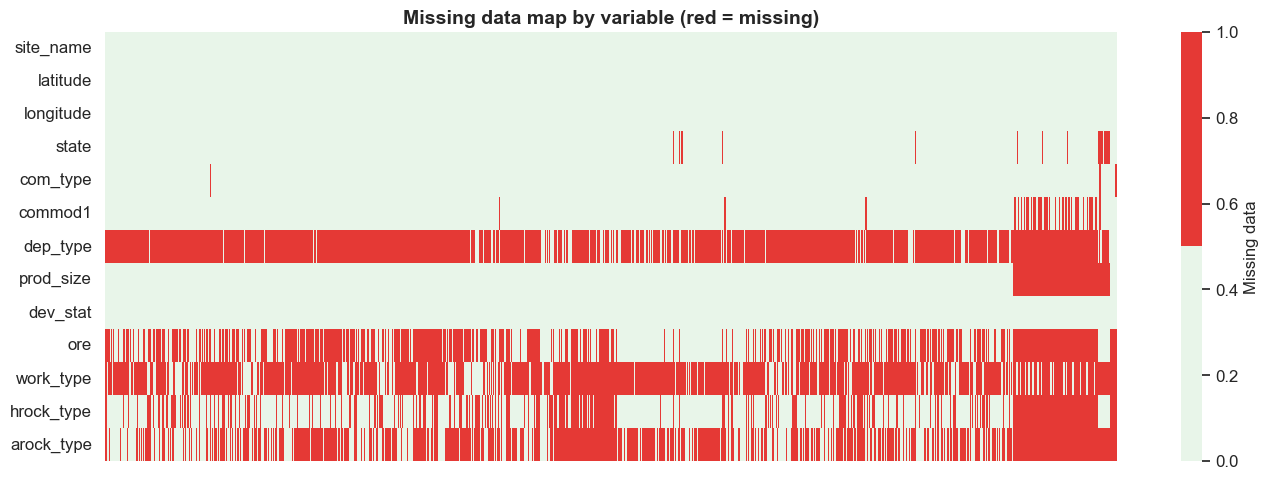

Variables with highest % of missing data:
   • dep_type: 89.4% missing
   • ore: 55.0% missing
   • work_type: 77.0% missing
   • hrock_type: 33.6% missing
   • arock_type: 66.0% missing


In [3]:
# 1.1 — Completeness analysis: null and empty values

# Calculate nulls + empty values per column
null_counts = df.isnull().sum()
empty_counts = df.eq("").sum()
total_missing = null_counts + empty_counts
pct_missing = (total_missing / len(df) * 100).round(1)

# Create summary
completeness = pd.DataFrame(
    {
        "Nulls": null_counts,
        "Empty": empty_counts,
        "Total missing": total_missing,
        "% missing": pct_missing,
        "% complete": (100 - pct_missing).round(1),
    }
).sort_values("% missing", ascending=False)

print("Dataset completeness analysis")
print(completeness.to_string())

# Visualization: nullity heatmap
fig, ax = plt.subplots(figsize=(14, 5))
missing_matrix = df.isnull() | df.eq("")
sns.heatmap(
    missing_matrix.T,
    cbar_kws={"label": "Missing data"},
    cmap=["#E8F5E9", "#E53935"],
    yticklabels=df.columns,
    xticklabels=False,
    ax=ax,
)
ax.set_title(
    "Missing data map by variable (red = missing)",
    fontsize=14,
    fontweight="bold",
)
ax.set_ylabel("")
plt.tight_layout()
plt.show()

print("Variables with highest % of missing data:")
for col, pct in pct_missing[pct_missing > 30].items():
    print(f"   • {col}: {pct}% missing")

In [4]:
# 1.2 — Standardization of work_type (extraction method)

print("BEFORE standardizing work_type:")
print(df["work_type"].value_counts(dropna=False))
print(
    f"Total empty/NaN: {df['work_type'].isna().sum() + df['work_type'].eq('').sum()}"
)

# Standardize: fill empty values with "Unknown"
df["work_type"] = df["work_type"].fillna("Unknown").replace("", "Unknown")

# Normalize variants
df["work_type"] = df["work_type"].str.strip()
# Unify "Surface, Underground" → "Surface/Underground"
df["work_type"] = df["work_type"].replace("Surface, Underground", "Surface/Underground")

print("---------------------------------")
print("AFTER standardizing work_type:")
print(df["work_type"].value_counts())
print(f"Total records: {len(df)}")

BEFORE standardizing work_type:
work_type
NaN                     2351
Underground              456
Surface                  159
Surface/Underground       67
Unknown                   15
Surface, Underground       7
Name: count, dtype: int64
Total empty/NaN: 2351
---------------------------------
AFTER standardizing work_type:
work_type
Unknown                2366
Underground             456
Surface                 159
Surface/Underground      74
Name: count, dtype: int64
Total records: 3055


In [5]:
# 1.3 — Standardization of prod_size (production scale)

print("BEFORE standardizing prod_size:")
print(df["prod_size"].value_counts(dropna=False))

# Map codes to descriptive labels
size_map = {
    "Y": "Grande",
    "L": "Grande",
    "M": "Mediano",
    "S": "Pequeño",
    "N": "Sin dato",
    "U": "Desconocido",
}

df["prod_size_label"] = df["prod_size"].map(size_map).fillna("Desconocido")

print("---------------------------------")

print("AFTER standardizing (new column prod_size_label):")
print(df["prod_size_label"].value_counts())

SIZE_ORDER = ["Grande", "Mediano", "Pequeño", "Sin dato", "Desconocido"]

BEFORE standardizing prod_size:
prod_size
S      918
Y      777
N      692
NaN    292
U      268
M       73
L       35
Name: count, dtype: int64
---------------------------------
AFTER standardizing (new column prod_size_label):
prod_size_label
Pequeño        918
Grande         812
Sin dato       692
Desconocido    560
Mediano         73
Name: count, dtype: int64


In [6]:
# 1.4 — Standardization of dev_stat (development status)

print("BEFORE standardizing dev_stat:")
print(df["dev_stat"].value_counts(dropna=False))


# Group into 5 main categories
def classify_dev_stat(val):
    if pd.isna(val) or val.strip() == "":
        return "Otros"
    val = val.strip()
    if val == "Producer":
        return "Producer"
    elif val == "Past Producer":
        return "Past Producer"
    elif val == "Prospect":
        return "Prospect"
    elif val == "Occurrence":
        return "Occurrence"
    else:
        return "Otros"


df["dev_stat_label"] = df["dev_stat"].apply(classify_dev_stat)

print("---------------------------------")

print("AFTER standardizing (new column dev_stat_label):")
print(df["dev_stat_label"].value_counts())

DEV_ORDER = ["Producer", "Past Producer", "Prospect", "Occurrence", "Otros"]

BEFORE standardizing dev_stat:
dev_stat
Occurrence       1258
Past Producer     752
Producer          648
Prospect          328
Plant              45
Unknown            24
Name: count, dtype: int64
---------------------------------
AFTER standardizing (new column dev_stat_label):
dev_stat_label
Occurrence       1258
Past Producer     752
Producer          648
Prospect          328
Otros              69
Name: count, dtype: int64


In [7]:
# 1.5 — Extract primary mineral from commod1

# commod1 contains one or more minerals separated by commas
# We extract only the first mineral as the primary mineral
df["mineral_principal"] = (
    df["commod1"].fillna("Desconocido").str.split(",").str[0].str.strip()
)

print("Top 15 primary minerals:")
print(df["mineral_principal"].value_counts().head(15))
print(f"Total unique minerals: {df['mineral_principal'].nunique()}")

Top 15 primary minerals:
mineral_principal
Copper         754
Silver         542
Lead           446
Zinc           303
Gold           282
Desconocido    165
Antimony        57
Iron            50
Bentonite       47
Limestone       45
Halite          38
Tungsten        31
Graphite        23
Molybdenum      20
Kaolin          19
Name: count, dtype: int64
Total unique minerals: 53


### Data Cleaning Summary

| Variable | Transformation | Result |
|----------|---------------|-----------|
| `work_type` | Empty/NaN values → `"Unknown"` | 4 categories: Underground, Surface, Surface/Underground, Unknown |
| `prod_size` | Codes (U/S/M/Y/L/N) → descriptive labels | New column `prod_size_label` with 5 categories |
| `dev_stat` | Grouping into main categories | New column `dev_stat_label` with 5 categories |
| `commod1` | Extraction of first mineral | New column `mineral_principal` |


**Analytical decision:** The high percentage of `work_type = Unknown` will be reported as a finding (information gap). For the analytical blocks, results will be presented both with the complete dataset and filtering only records with known method, where relevant.

---

---

## Block 1 — National Diagnosis of Extraction Method

**Sub-question:** What is the predominant extraction method in Peru?

This block establishes the analysis baseline. Before cross-referencing the method with other variables, we need to understand the general distribution of extraction methods across the entire Peruvian territory.

**Key indicators:**
- Absolute and percentage frequency of each method
- Ambiguity level (% Unknown) as an information gap indicator

Distribution of mining extraction methods in Peru
                     Frequency  Percentage (%)
work_type                                     
Underground                456            14.9
Surface                    159             5.2
Surface/Underground         74             2.4
Unknown                   2366            77.4


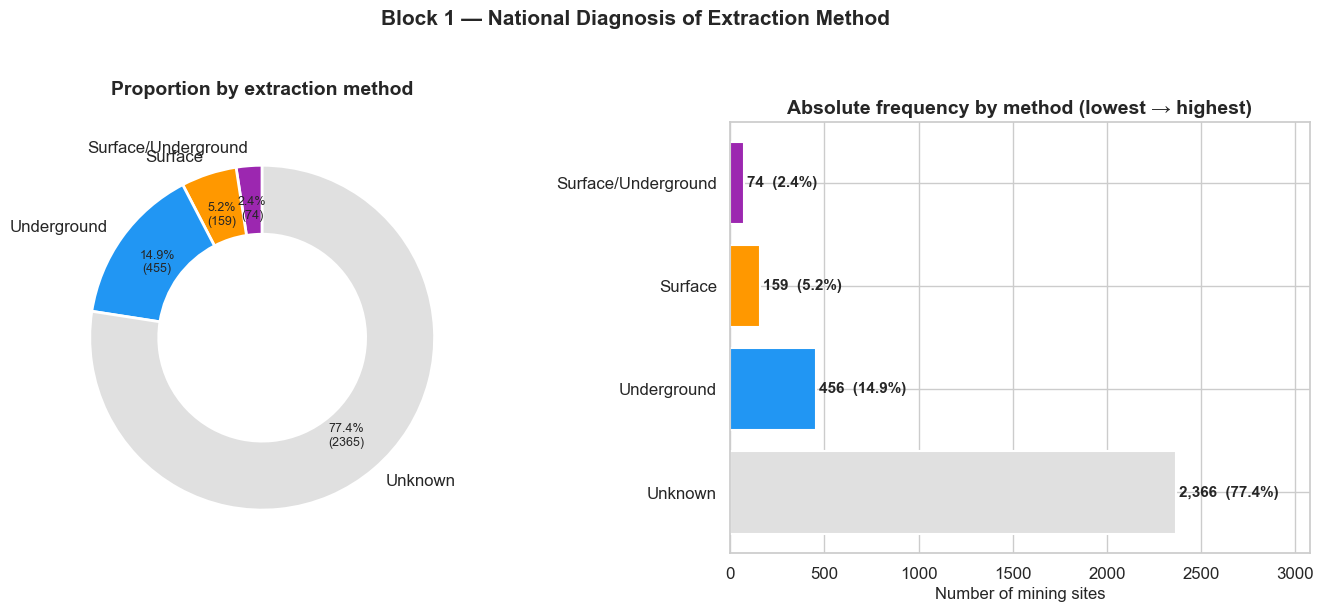

JSON file saved successfully.


In [8]:
# BLOCK 1.1 — General distribution of extraction method

# Absolute and percentage frequencies
method_counts = df["work_type"].value_counts().reindex(METHOD_ORDER)
method_pcts = (method_counts / method_counts.sum() * 100).round(1)

method_summary = pd.DataFrame(
    {"Frequency": method_counts, "Percentage (%)": method_pcts}
)
print("Distribution of mining extraction methods in Peru")
print(method_summary.to_string())

# Sort from lowest to highest frequency for visualization
sort_asc = method_counts.sort_values(ascending=True).index

# --- Visualization: Donut + Bar ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left panel: Donut chart (sorted from lowest to highest)
colors_donut = [METHOD_COLORS[m] for m in sort_asc]
wedges, texts, autotexts = axes[0].pie(
    method_counts[sort_asc].values,
    labels=sort_asc,
    colors=colors_donut,
    autopct=lambda p: f"{p:.1f}%\n({int(p * method_counts.sum() / 100)})",
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.4, edgecolor="white", linewidth=2),
)
for autotext in autotexts:
    autotext.set_fontsize(9)
axes[0].set_title("Proportion by extraction method", fontweight="bold", pad=20)

# Right panel: Horizontal bar chart (lowest on top → highest on bottom)
sort_desc = method_counts.sort_values(ascending=False).index
bars = axes[1].barh(
    sort_desc,
    method_counts[sort_desc].values,
    color=[METHOD_COLORS[m] for m in sort_desc],
    edgecolor="white",
    linewidth=1.5,
)
for bar, count, pct in zip(
    bars, method_counts[sort_desc].values, method_pcts[sort_desc].values
):
    axes[1].text(
        bar.get_width() + 15,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,}  ({pct}%)",
        va="center",
        fontsize=11,
        fontweight="bold",
    )
axes[1].set_xlabel("Number of mining sites")
axes[1].set_title("Absolute frequency by method (lowest → highest)", fontweight="bold")
axes[1].set_xlim(0, method_counts.max() * 1.3)

fig.suptitle(
    "Block 1 — National Diagnosis of Extraction Method",
    fontsize=15,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

# Export data for frontend visualization (JSON)
# Create exportable structure
export_data = []

for method in method_counts.index:
    export_data.append({
        "method": method,
        "frequency": int(method_counts[method]),
        "percentage": float(method_pcts[method]),
    })

# Save JSON file
with open("../../frontend/src/data/B1/bloque_1_metodos_extraccion.json", "w", encoding="utf-8") as f:
    json.dump(export_data, f, indent=4, ensure_ascii=False)

print("JSON file saved successfully.")

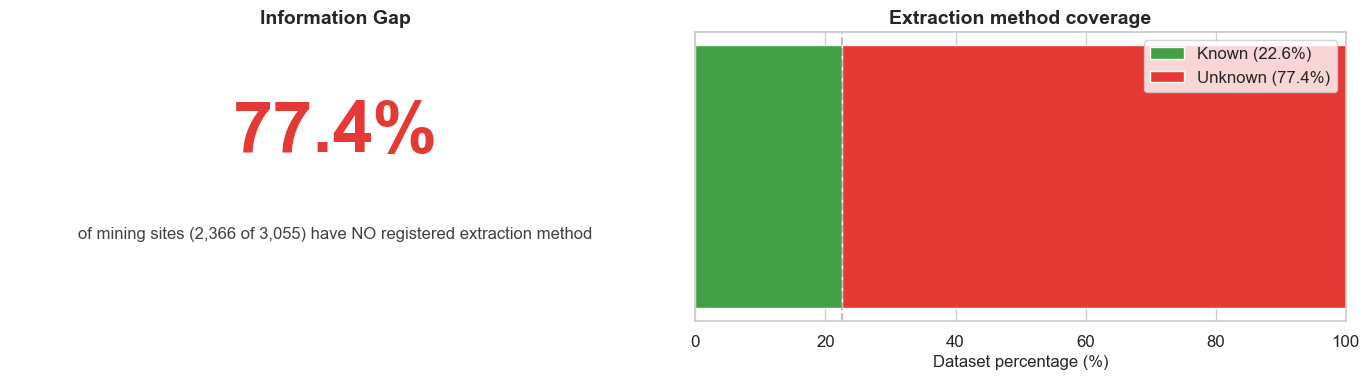

Subset with known method: 689 records (22.6% of total)
   This subset will be used for cross-analyses where relevant.
Information gap JSON file saved successfully.


In [9]:
# BLOCK 1.2 — Information gap indicator (visual KPI)

unknown_count = method_counts.get("Unknown", 0)
unknown_pct = unknown_count / len(df) * 100
known_count = len(df) - unknown_count
known_pct = 100 - unknown_pct

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left panel: Information gap KPI
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].text(
    0.5,
    0.65,
    f"{unknown_pct:.1f}%",
    ha="center",
    va="center",
    fontsize=52,
    fontweight="bold",
    color="#E53935",
)
axes[0].text(
    0.5,
    0.30,
    f"of mining sites ({unknown_count:,} of {len(df):,}) have NO registered extraction method",
    ha="center",
    va="center",
    fontsize=12,
    color="#424242",
)
axes[0].set_title("Information Gap", fontsize=14, fontweight="bold")
axes[0].axis("off")

# Right panel: Visual progress bar
axes[1].barh(
    [""], [known_pct], color="#43A047", height=0.4, label=f"Known ({known_pct:.1f}%)"
)
axes[1].barh(
    [""],
    [unknown_pct],
    left=[known_pct],
    color="#E53935",
    height=0.4,
    label=f"Unknown ({unknown_pct:.1f}%)",
)
axes[1].set_xlim(0, 100)
axes[1].set_xlabel("Dataset percentage (%)")
axes[1].set_title("Extraction method coverage", fontweight="bold")
axes[1].legend(loc="upper right", frameon=True)
axes[1].axvline(x=known_pct, color="gray", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Subset with known method (for subsequent blocks)
df_known = df[df["work_type"] != "Unknown"].copy()
print(
    f"Subset with known method: {len(df_known)} records ({known_pct:.1f}% of total)"
)
print("   This subset will be used for cross-analyses where relevant.")


# Export data for frontend visualization (JSON)
# Build data structure used in the visualization
brecha_data = {
    "total_registros": int(len(df)),
    "unknown_count": int(unknown_count),
    "unknown_pct": round(float(unknown_pct), 2),
    "known_count": int(known_count),
    "known_pct": round(float(known_pct), 2)
}

# Save JSON file
with open("../../frontend/src/data/B1/bloque_1_brecha_informativa.json", "w", encoding="utf-8") as f:
    json.dump(brecha_data, f, indent=4, ensure_ascii=False)

print("Information gap JSON file saved successfully.")

### Insight — Block 1: National Diagnosis

**Key findings:**

1. **Dominant information gap:** The majority of mining sites have no registered extraction method ("Unknown"), reflecting a significant information gap in Peru's mining records. This is typical in databases of occurrences and prospects that have not yet reached the exploitation phase.

2. **Among sites with known method:** Underground mining is the predominant method, consistent with:
   - Peru's Andean mining tradition, where polymetallic veins (Zn, Pb, Ag) are mined underground.
   - The dominant geology: vein-type deposits in mountain ranges.

3. **Surface/Underground** (mixed operations) appears as a minor but significant category, indicating operations that combine both methods.

**Implication for the analysis:** In the following blocks, we will compare results using the complete dataset vs. only records with known method (`df_known`) to prevent the mass of "Unknown" from distorting the conclusions.

---

## Block 2 — Extraction Method vs. Mineral Type Relationship

**Sub-question:** Does underground mining concentrate on specific minerals?

Geology conditions the extraction method: **vein-type** deposits (Au, Ag, Zn, Pb) tend to be mined underground, while **porphyry** or **disseminated** deposits (Cu, Mo) favor open-pit (surface) operations.

**Procedure:**
1. Select the Top 10 primary minerals by frequency
2. Cross table: Mineral × Method
3. Interpret geological relationship

In [10]:
# BLOCK 2.1 — Cross table: Primary mineral × Method

# Top 10 primary minerals
top_minerals = df["mineral_principal"].value_counts().head(10).index.tolist()
df_top = df[df["mineral_principal"].isin(top_minerals)].copy()

print(f"Top 10 primary minerals ({len(df_top)} records out of {len(df)}):\n")
for i, mineral in enumerate(top_minerals, 1):
    count = df[df["mineral_principal"] == mineral].shape[0]
    print(f"   {i:2d}. {mineral}: {count}")

# Cross table (absolute frequencies)
ct_abs = pd.crosstab(
    df_top["mineral_principal"],
    df_top["work_type"],
    margins=True,
)
ct_abs = ct_abs.reindex(
    columns=[c for c in METHOD_ORDER if c in ct_abs.columns] + ["All"]
)
ct_abs = ct_abs.reindex(index=top_minerals + ["All"])

print("Cross table (absolute frequencies):")
print(ct_abs.to_string())

Top 10 primary minerals (2691 records out of 3055):

    1. Copper: 754
    2. Silver: 542
    3. Lead: 446
    4. Zinc: 303
    5. Gold: 282
    6. Desconocido: 165
    7. Antimony: 57
    8. Iron: 50
    9. Bentonite: 47
   10. Limestone: 45
Cross table (absolute frequencies):
work_type          Underground  Surface  Surface/Underground  Unknown   All
mineral_principal                                                          
Copper                     140       45                   25      544   754
Silver                     105       19                   19      399   542
Lead                        69       11                    8      358   446
Zinc                        39        5                    6      253   303
Gold                        43        6                    2      231   282
Desconocido                 27        5                    1      132   165
Antimony                    10        3                    5       39    57
Iron                         1      

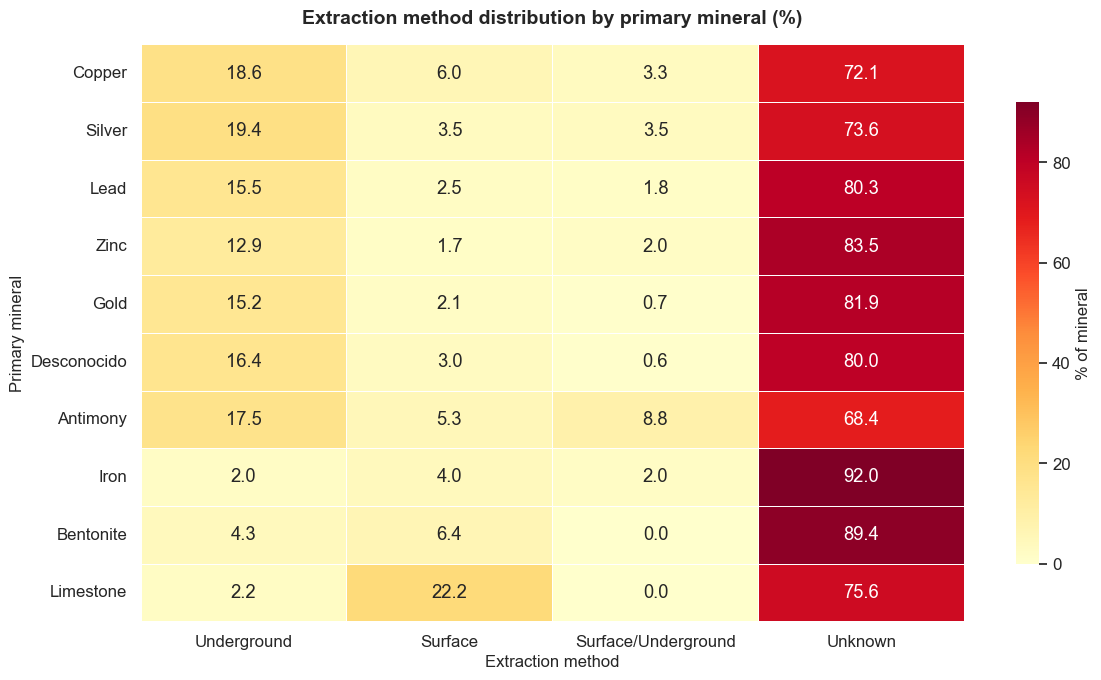

Heatmap JSON file saved successfully.


In [11]:
# BLOCK 2.2 — Proportion heatmap: Mineral × Method

# Percentage cross table (by row = by mineral)
ct_pct = (
    pd.crosstab(
        df_top["mineral_principal"],
        df_top["work_type"],
        normalize="index",
    )
    * 100
)

# Reorder
cols_present = [c for c in METHOD_ORDER if c in ct_pct.columns]
ct_pct = ct_pct.reindex(columns=cols_present)
ct_pct = ct_pct.reindex(index=top_minerals)

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(
    ct_pct,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "% of mineral", "shrink": 0.8},
    ax=ax,
)
ax.set_title(
    "Extraction method distribution by primary mineral (%)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Extraction method")
ax.set_ylabel("Primary mineral")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

# Export data for frontend visualization (JSON)

# Convert percentage cross table to exportable format
heatmap_data = {
    "minerals": list(ct_pct.index),
    "methods": list(ct_pct.columns),
    "values": ct_pct.round(2).values.tolist()
}

# Save JSON file
with open("../../frontend/src/data/B2/bloque_2_heatmap_mineral_metodo.json", "w", encoding="utf-8") as f:
    json.dump(heatmap_data, f, indent=4, ensure_ascii=False)

print("Heatmap JSON file saved successfully.")

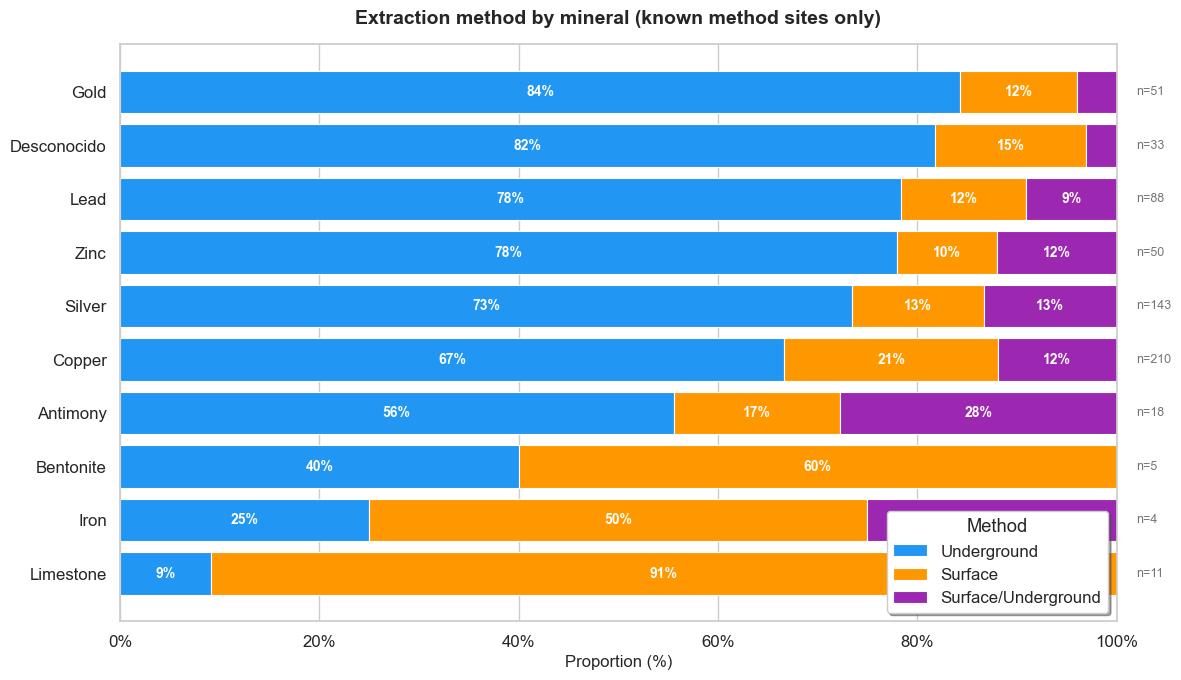

Total records with known method in Top 10 minerals: 613
100% stacked bar JSON file saved successfully.


In [12]:
# BLOCK 2.3 — 100% Stacked Bar: Mineral × Method (known method only)

# Filter only records with known method for a clearer view
df_top_known = df_top[df_top["work_type"] != "Unknown"].copy()

ct_known_pct = (
    pd.crosstab(
        df_top_known["mineral_principal"],
        df_top_known["work_type"],
        normalize="index",
    )
    * 100
)

# Sort by % Underground descending
methods_known = [
    m
    for m in ["Underground", "Surface", "Surface/Underground"]
    if m in ct_known_pct.columns
]
ct_known_pct = ct_known_pct.reindex(columns=methods_known)
if "Underground" in ct_known_pct.columns:
    ct_known_pct = ct_known_pct.sort_values("Underground", ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))

# 100% stacked horizontal bar
left = np.zeros(len(ct_known_pct))
for method in methods_known:
    if method in ct_known_pct.columns:
        values = ct_known_pct[method].values
        bars = ax.barh(
            ct_known_pct.index,
            values,
            left=left,
            color=METHOD_COLORS[method],
            label=method,
            edgecolor="white",
            linewidth=0.8,
        )
        # Annotate percentage if > 8%
        for bar, val, lef in zip(bars, values, left):
            if val > 8:
                ax.text(
                    lef + val / 2,
                    bar.get_y() + bar.get_height() / 2,
                    f"{val:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=10,
                    fontweight="bold",
                    color="white",
                )
        left += values

ax.set_xlim(0, 100)
ax.set_xlabel("Proportion (%)")
ax.set_title(
    "Extraction method by mineral (known method sites only)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
ax.legend(
    title="Method",
    loc="lower right",
    frameon=True,
    fancybox=True,
    shadow=True,
)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())

# Add n for each mineral
for i, mineral in enumerate(ct_known_pct.index):
    n = len(df_top_known[df_top_known["mineral_principal"] == mineral])
    ax.text(102, i, f"n={n}", va="center", fontsize=9, color="#757575")

plt.tight_layout()
plt.show()

print(
    f"Total records with known method in Top 10 minerals: {len(df_top_known)}"
)

# Export data for frontend visualization (JSON)
# Calculate sample size per mineral
sample_sizes = {
    mineral: int(len(df_top_known[df_top_known["mineral_principal"] == mineral]))
    for mineral in ct_known_pct.index
}

# Build exportable structure
stacked_data = {
    "minerals": list(ct_known_pct.index),
    "methods": methods_known,
    "values": ct_known_pct.round(2).values.tolist(),
    "sample_size_per_mineral": sample_sizes,
    "total_known_records_top10": int(len(df_top_known))
}

# Save JSON file
with open("../../frontend/src/data/B2/bloque_2_stacked_mineral_metodo_known.json", "w", encoding="utf-8") as f:
    json.dump(stacked_data, f, indent=4, ensure_ascii=False)

print("100% stacked bar JSON file saved successfully.")

### Insight — Block 2: Method–Mineral Relationship

**Key findings:**

1. **Mineral type conditions the extraction method**, confirming the geological hypothesis:
   - **Copper (Cu):** Higher proportion of Surface, consistent with large-scale porphyry deposits (open pit).
   - **Gold (Au):** Underground predominates, associated with vein-type deposits in Andean zones.
   - **Zinc, Lead, Silver (Zn, Pb, Ag):** Strong Underground dominance, typical of polymetallic veins.

2. **Geological connection:**
   - **Vein-type deposits** (narrow, deep) → Underground: Ag, Pb, Zn, Au
   - **Disseminated/porphyry deposits** (broad, shallow) → Surface: Cu, Mo

3. **Surface/Underground** appears in minerals like Cu and Au, suggesting complex operations that combine both methods depending on the depth of the ore body.

**Partial conclusion:** There is a clear relationship between mineral type and extraction method, mediated by the deposit geology. This relationship is one of the most robust patterns in the analysis.

---

## Block 3 — Territorial Distribution of Extraction Method

**Sub-question:** Are there regions where one method clearly dominates?

Peru has a geological diversity shaped by the Andes Mountain Range, which defines metallogenic belts with distinct characteristics. This block explores whether the extraction method presents **territorial clusters** or if its distribution is uniform at the national level.

**Procedure:**
1. Cross table: Region × Method (proportions)
2. Identify regions with >60% of one method
3. Scatter and density maps with real coordinates

In [13]:
# BLOCK 3.1 — Cross table: Region × Extraction method

# Percentage cross table by region
ct_region = (
    pd.crosstab(
        df["state"],
        df["work_type"],
        normalize="index",
    )
    * 100
)
cols_for_region = [c for c in METHOD_ORDER if c in ct_region.columns]
ct_region = ct_region.reindex(columns=cols_for_region)

# Add column for total sites per region
region_totals = df["state"].value_counts()
ct_region["n_total"] = region_totals

# Identify regions with clear dominance (>60% of one method, excluding Unknown)
ct_region_known = (
    pd.crosstab(
        df_known["state"],
        df_known["work_type"],
        normalize="index",
    )
    * 100
)

print("Regions with clear method dominance (>60%, excluding Unknown):\n")
for method in ["Underground", "Surface", "Surface/Underground"]:
    if method in ct_region_known.columns:
        dominant = ct_region_known[ct_region_known[method] > 60].index.tolist()
        if dominant:
            print(f"   {method}:")
            for region in dominant:
                pct = ct_region_known.loc[region, method]
                n = len(df_known[df_known["state"] == region])
                print(f"      • {region}: {pct:.1f}% (n={n})")
            print()
            
            
# Export Region × Method data (absolute values) for frontend (JSON)
# Cross table with absolute counts
ct_region_counts = pd.crosstab(
    df_known["state"],
    df_known["work_type"]
)

# Build exportable structure
region_data = []

for region in ct_region_counts.index:
    row = ct_region_counts.loc[region]
    total_known = int(row.sum())
    
    # Dominant method (highest absolute count)
    dominant_method = row.idxmax()
    dominant_count = int(row.max())
    
    region_data.append({
        "region": region,
        "total_known_sites": total_known,
        "methods_counts": {
            method: int(row[method])
            for method in row.index
        },
        "dominant_method": dominant_method,
        "dominant_count": dominant_count
    })

# Save JSON
with open("../../frontend/src/data/B3/bloque_3_region_metodo_absoluto.json", "w", encoding="utf-8") as f:
    json.dump(region_data, f, indent=4, ensure_ascii=False)

print("Region × Method JSON file (absolute values) saved successfully.")

Regions with clear method dominance (>60%, excluding Unknown):

   Underground:
      • Ancash: 71.7% (n=53)
      • Apurimac: 61.1% (n=36)
      • Arequipa: 82.9% (n=82)
      • Ayacucho: 88.9% (n=36)
      • Cajamarca: 63.2% (n=19)
      • Huancavelica: 83.3% (n=18)
      • Huanuco: 73.7% (n=19)
      • Ica: 68.4% (n=38)
      • Junin: 67.9% (n=28)
      • Pasco: 83.3% (n=36)
      • Puno: 70.9% (n=110)
      • Tacna: 63.9% (n=36)

   Surface:
      • Lambayeque: 100.0% (n=1)
      • Piura: 75.0% (n=4)

Region × Method JSON file (absolute values) saved successfully.


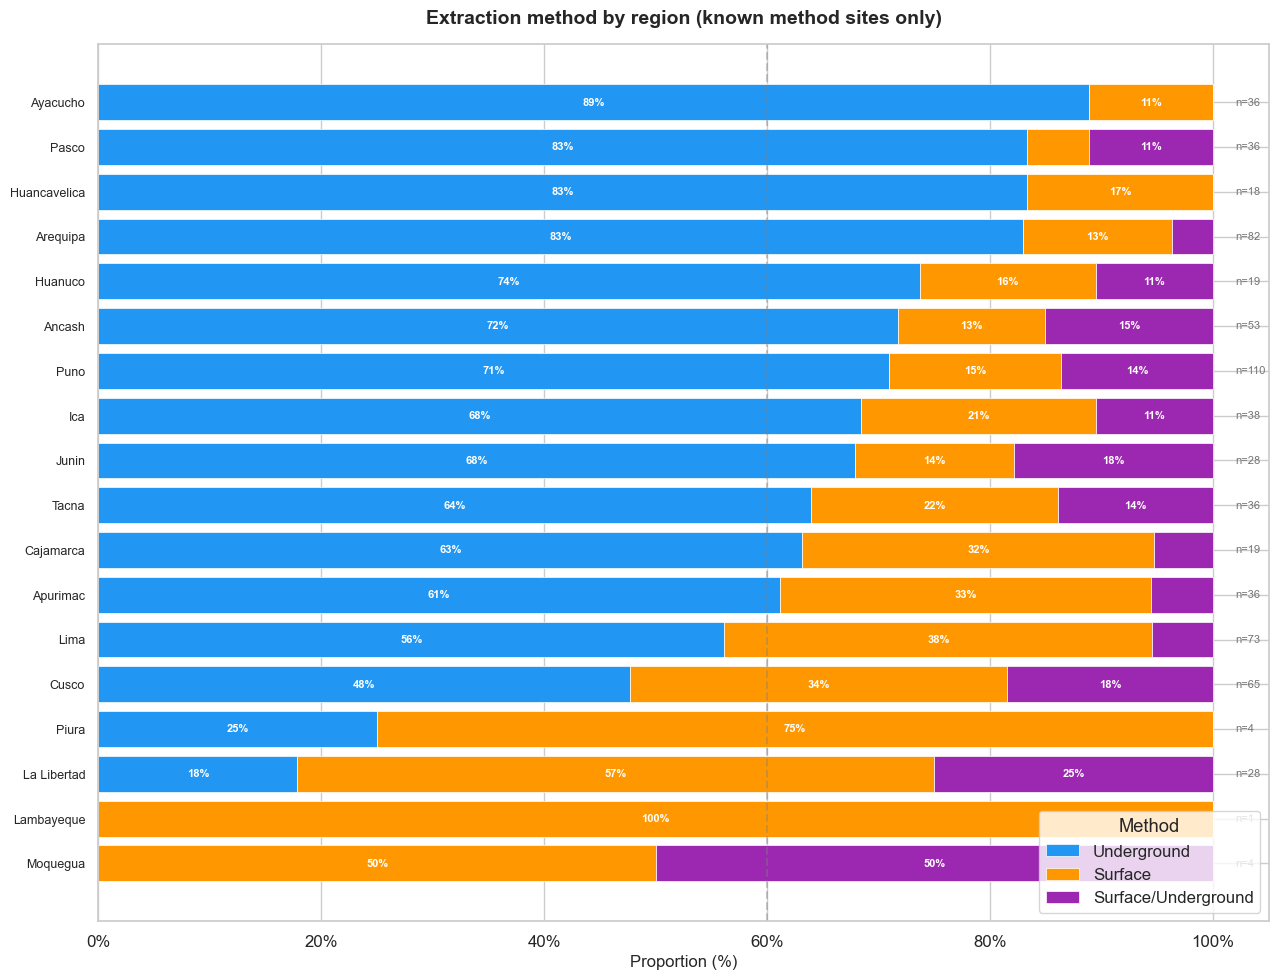

In [14]:
# BLOCK 3.2 — Horizontal stacked bar: Region × Method

# Sort regions by % Underground (excluding Unknown)
if "Underground" in ct_region_known.columns:
    region_order = ct_region_known.sort_values("Underground", ascending=True).index
else:
    region_order = ct_region_known.index

fig, ax = plt.subplots(figsize=(13, 10))

methods_plot = [
    m
    for m in ["Underground", "Surface", "Surface/Underground"]
    if m in ct_region_known.columns
]
left = np.zeros(len(region_order))

for method in methods_plot:
    values = ct_region_known.reindex(region_order)[method].fillna(0).values
    bars = ax.barh(
        range(len(region_order)),
        values,
        left=left,
        color=METHOD_COLORS[method],
        label=method,
        edgecolor="white",
        linewidth=0.5,
    )
    for j, (bar, val, l_val) in enumerate(zip(bars, values, left)):
        if val > 10:
            ax.text(
                l_val + val / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{val:.0f}%",
                ha="center",
                va="center",
                fontsize=8,
                fontweight="bold",
                color="white",
            )
    left += values

ax.set_yticks(range(len(region_order)))
ax.set_yticklabels(region_order, fontsize=9)
ax.set_xlim(0, 105)
ax.set_xlabel("Proportion (%)")
ax.set_title(
    "Extraction method by region (known method sites only)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
ax.legend(title="Method", loc="lower right", frameon=True)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())

# Add n per region
for i, region in enumerate(region_order):
    n = len(df_known[df_known["state"] == region])
    ax.text(102, i, f"n={n}", va="center", fontsize=8, color="#757575")

# Reference line at 60%
ax.axvline(x=60, color="gray", linestyle="--", alpha=0.4, label="60% threshold")

plt.tight_layout()
plt.show()

In [15]:
# BLOCK 3.3 — Interactive scatter map (Plotly)

# Scatter map: each point = a mining site, colored by method
color_map = {k: v for k, v in METHOD_COLORS.items()}

fig_scatter = px.scatter_mapbox(
    df,
    lat="latitude",
    lon="longitude",
    color="work_type",
    color_discrete_map=color_map,
    category_orders={"work_type": METHOD_ORDER},
    hover_name="site_name",
    hover_data={
        "state": True,
        "mineral_principal": True,
        "work_type": True,
        "latitude": False,
        "longitude": False,
    },
    title="Map of Peruvian mining sites by extraction method",
    mapbox_style="open-street-map",
    zoom=4.5,
    center={"lat": -9.19, "lon": -75.0},
    height=650,
    opacity=0.7,
)

fig_scatter.update_layout(
    legend_title_text="Extraction method",
    margin=dict(l=0, r=0, t=50, b=0),
)
fig_scatter.show()



# Export sample of mining sites with valid coordinates for frontend visualization (GeoJSON)

df_valid = df.dropna(subset=["latitude", "longitude"]).copy()

# Remove 0,0 coordinates if they exist
df_valid = df_valid[
    (df_valid["latitude"] != 0) &
    (df_valid["longitude"] != 0)
]

df_valid["work_type"] = df_valid["work_type"].fillna("Unknown")
df_valid["state"] = df_valid["state"].fillna("Unknown")
df_valid["mineral_principal"] = df_valid["mineral_principal"].fillna("Unknown")

df_sample = (
    df_valid
    .sort_values("site_name")   # for consistency
    .groupby("work_type", group_keys=False)
    .head(10)
)

print("Records per method:")
print(df_sample["work_type"].value_counts())

geojson_data = {
    "type": "FeatureCollection",
    "features": []
}

for _, row in df_sample.iterrows():
    feature = {
        "type": "Feature",
        "properties": {
            "site_name": row["site_name"],
            "state": row["state"],
            "mineral_principal": row["mineral_principal"],
            "work_type": row["work_type"]
        },
        "geometry": {
            "type": "Point",
            "coordinates": [
                float(row["longitude"]),  # IMPORTANT: lon first
                float(row["latitude"])
            ]
        }
    }
    geojson_data["features"].append(feature)

output_file = "../../frontend/src/data/B3/bloque_3_sitios_mineros_muestra.geojson"

with open(output_file, "w", encoding="utf-8") as f:
    json.dump(geojson_data, f, indent=4, ensure_ascii=False)

C:\Users\DAVID\AppData\Local\Temp\ipykernel_14792\1489240977.py:6: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig_scatter = px.scatter_mapbox(


Records per method:
work_type
Unknown                10
Underground            10
Surface/Underground    10
Surface                10
Name: count, dtype: int64


In [16]:
# BLOCK 3.4 — Density map (territorial heatmap)

# Only sites with known method, one map per method
fig_density = px.density_mapbox(
    df_known,
    lat="latitude",
    lon="longitude",
    radius=12,
    mapbox_style="open-street-map",
    zoom=4.2,
    center={"lat": -9.19, "lon": -75.0},
    title="Density of mining sites with known method",
    height=550,
    opacity=0.6,
)
fig_density.update_layout(
    margin=dict(l=0, r=0, t=50, b=0),
    paper_bgcolor="black",
    plot_bgcolor="black",
    font=dict(color="white")
)
fig_density.show()


# Density maps by method (subplots)
known_methods = [m for m in ["Underground", "Surface", "Surface/Underground"] if m in df_known["work_type"].unique()]

fig_by_method = make_subplots(
    rows=1, cols=len(known_methods),
    subplot_titles=[f"Density: {m}" for m in known_methods],
    specs=[[{"type": "mapbox"}] * len(known_methods)],
    horizontal_spacing=0.02,
)


for i, method in enumerate(known_methods, 1):
    df_m = df_known[df_known["work_type"] == method]
    fig_by_method.add_trace(
        go.Densitymapbox(
            lat=df_m["latitude"],
            lon=df_m["longitude"],
            radius=15,
            opacity=0.6,
            colorscale="Hot",
            showscale=False,
            name=method,
        ),
        row=1, col=i,
    )
    fig_by_method.update_layout(**{
        f"mapbox{'' if i == 1 else i}": dict(
            style="open-street-map",
            center=dict(lat=-9.19, lon=-75.0),
            zoom=3.8,
        )
    })

fig_by_method.update_layout(
    height=450,
    title_text="Site density by extraction method",
    margin=dict(l=0, r=0, t=60, b=0),
    paper_bgcolor="black",
    plot_bgcolor="black",
    font=dict(color="white")
)
fig_by_method.show()

C:\Users\DAVID\AppData\Local\Temp\ipykernel_14792\491150648.py:4: DeprecationWarning:

*density_mapbox* is deprecated! Use *density_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



C:\Users\DAVID\AppData\Local\Temp\ipykernel_14792\491150648.py:39: DeprecationWarning:

*densitymapbox* is deprecated! Use *densitymap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

C:\Users\DAVID\AppData\Local\Temp\ipykernel_14792\491150648.py:39: DeprecationWarning:

*densitymapbox* is deprecated! Use *densitymap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

C:\Users\DAVID\AppData\Local\Temp\ipykernel_14792\491150648.py:39: DeprecationWarning:

*densitymapbox* is deprecated! Use *densitymap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



### Insight — Block 3: Territorial Distribution

**Key findings:**

1. **Territorial clusters identified:**
   - **Central Andes (Junín, Pasco, Lima, Ancash, Huancavelica):** High concentration of Underground mining, consistent with the polymetallic vein belt of Zn-Pb-Ag.
   - **Southern Andes (Arequipa, Cusco, Apurímac, Tacna, Moquegua):** Greater Surface presence, associated with the large porphyry Cu deposits (copper corridor).
   - **North and jungle (Amazonas, Cajamarca, La Libertad):** Underground predominates for vein-type gold deposits.

2. **Clear geographic pattern:** The distribution of methods is NOT uniform — it follows the geology of Peru's metallogenic belts.

3. **Density maps** confirm that mining activity is concentrated along the Andes Mountain Range, with the main hotspots in the central Andes.

**Partial conclusion:** There is a robust territorial pattern connecting regional geology with the extraction method. Southern regions show greater method diversification, while the central Andes are predominantly underground.

---

## Block 4 — Extraction Method and Production Scale

**Sub-question:** Is the extraction method associated with production size?

Production scale (small, medium, large) has direct implications for the technology, investment, and extraction method used. The hypothesis is that:
- **Surface (open pit)** is associated with **large-scale** operations (economies of scale, higher capital investment).
- **Underground** is more associated with **small and medium-scale** operations (lower initial investment, greater selectivity).

**Procedure:**
1. Cross table: Method × Production scale
2. Exclude "Desconocido" for clean analysis
3. Analyze bidirectional proportions

In [17]:
# BLOCK 4.1 — Cross table: Method × Production scale

# Filter records with known method AND informative scale
df_scale = df_known[~df_known["prod_size_label"].isin(["Desconocido"])].copy()

# Absolute cross table
ct_scale_abs = pd.crosstab(
    df_scale["work_type"],
    df_scale["prod_size_label"],
)
scale_cols = [
    c for c in ["Grande", "Mediano", "Pequeño", "Sin dato"] if c in ct_scale_abs.columns
]
ct_scale_abs = ct_scale_abs.reindex(columns=scale_cols)
ct_scale_abs = ct_scale_abs.reindex(
    index=[m for m in METHOD_ORDER if m in ct_scale_abs.index]
)

# Percentage table (by method)
ct_scale_pct = ct_scale_abs.div(ct_scale_abs.sum(axis=1), axis=0) * 100

print(
    f"Method × Production scale (n={len(df_scale)}, excluding 'Desconocido' scale)"
)
print("Absolute frequencies:")
print(ct_scale_abs.to_string())
print("Percentages by method (%):")
print(ct_scale_pct.round(1).to_string())


# Export cross tables in JSON format for frontend
ct_abs_dict = ct_scale_abs.to_dict(orient="index")
ct_pct_dict = ct_scale_pct.round(2).to_dict(orient="index")


json_output = {
    "metadata": {
        "analysis": "Metodo vs Escala productiva",
        "total_registros": int(len(df_scale)),
        "exclusion": "Escala 'Desconocido'"
    },
    "tabla_absoluta": ct_abs_dict,
    "tabla_porcentual": ct_pct_dict
}


output_file = "../../frontend/src/data/B4/bloque_4_metodo_vs_escala.json"

with open(output_file, "w", encoding="utf-8") as f:
    json.dump(json_output, f, indent=4, ensure_ascii=False)

print(f"File saved as: {output_file}")

Method × Production scale (n=557, excluding 'Desconocido' scale)
Absolute frequencies:
prod_size_label      Grande  Mediano  Pequeño  Sin dato
work_type                                              
Underground             143       24      167        43
Surface                  26        1       59        30
Surface/Underground      24        3       32         5
Percentages by method (%):
prod_size_label      Grande  Mediano  Pequeño  Sin dato
work_type                                              
Underground            37.9      6.4     44.3      11.4
Surface                22.4      0.9     50.9      25.9
Surface/Underground    37.5      4.7     50.0       7.8
File saved as: ../../frontend/src/data/B4/bloque_4_metodo_vs_escala.json


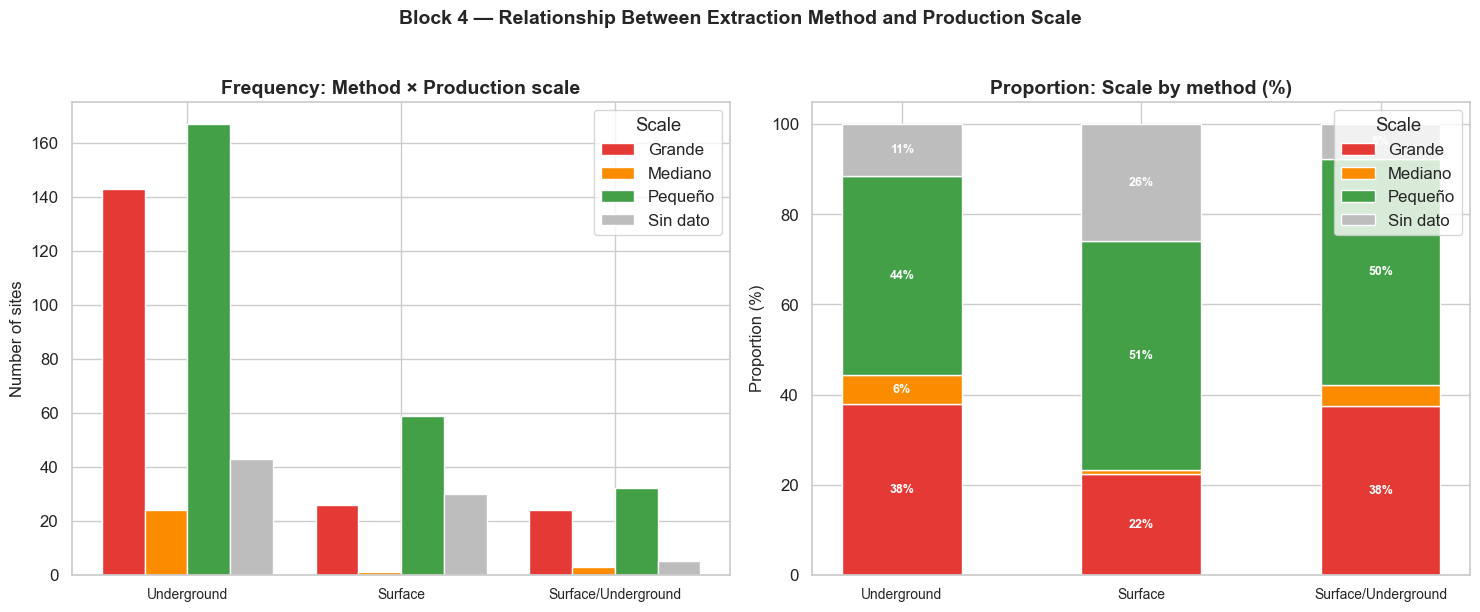

File saved successfully: ../../frontend/src/data/B4/bloque_4_metodo_vs_escala_grafica.json


In [18]:
# BLOCK 4.2 — Visualization: Method × Production scale

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Left panel: Grouped bar chart ---
x_methods = [m for m in METHOD_ORDER if m in ct_scale_abs.index]
x_pos = np.arange(len(x_methods))
bar_width = 0.2

for i, size in enumerate(scale_cols):
    values = [
        ct_scale_abs.loc[m, size]
        if m in ct_scale_abs.index and size in ct_scale_abs.columns
        else 0
        for m in x_methods
    ]
    color = SIZE_COLORS.get(size, "#999999")
    axes[0].bar(
        x_pos + i * bar_width,
        values,
        bar_width,
        label=size,
        color=color,
        edgecolor="white",
    )

axes[0].set_xticks(x_pos + bar_width * (len(scale_cols) - 1) / 2)
axes[0].set_xticklabels(x_methods, fontsize=10)
axes[0].set_ylabel("Number of sites")
axes[0].set_title("Frequency: Method × Production scale", fontweight="bold")
axes[0].legend(title="Scale", frameon=True)

# --- Right panel: 100% stacked bar ---
left = np.zeros(len(x_methods))
for size in scale_cols:
    values = [
        ct_scale_pct.loc[m, size]
        if m in ct_scale_pct.index and size in ct_scale_pct.columns
        else 0
        for m in x_methods
    ]
    color = SIZE_COLORS.get(size, "#999999")
    bars = axes[1].bar(
        x_pos, values, 0.5, bottom=left, label=size, color=color, edgecolor="white"
    )
    for j, (val, l_val) in enumerate(zip(values, left)):
        if val > 5:
            axes[1].text(
                x_pos[j],
                l_val + val / 2,
                f"{val:.0f}%",
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold",
                color="white",
            )
    left += np.array(values)

axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(x_methods, fontsize=10)
axes[1].set_ylabel("Proportion (%)")
axes[1].set_ylim(0, 105)
axes[1].set_title("Proportion: Scale by method (%)", fontweight="bold")
axes[1].legend(title="Scale", frameon=True, loc="upper right")

fig.suptitle(
    "Block 4 — Relationship Between Extraction Method and Production Scale",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()


# Export data for frontend visualization (JSON)

x_methods = [m for m in METHOD_ORDER if m in ct_scale_abs.index]

data_export = {
    "metadata": {
        "analysis": "Metodo vs Escala productiva",
        "total_registros": int(len(df_scale)),
        "metodos": x_methods,
        "escalas": scale_cols
    },
    "frecuencia_absoluta": [],
    "proporcion_porcentual": []
}

for method in x_methods:
    row = {"method": method}
    for size in scale_cols:
        row[size] = int(
            ct_scale_abs.loc[method, size]
            if method in ct_scale_abs.index and size in ct_scale_abs.columns
            else 0
        )
    data_export["frecuencia_absoluta"].append(row)

for method in x_methods:
    row = {"method": method}
    for size in scale_cols:
        row[size] = round(
            float(
                ct_scale_pct.loc[method, size]
                if method in ct_scale_pct.index and size in ct_scale_pct.columns
                else 0
            ),
            2
        )
    data_export["proporcion_porcentual"].append(row)

output_file = "../../frontend/src/data/B4/bloque_4_metodo_vs_escala_grafica.json"

with open(output_file, "w", encoding="utf-8") as f:
    json.dump(data_export, f, indent=4, ensure_ascii=False)

print(f"File saved successfully: {output_file}")

### Insight — Block 4: Method and Production Scale

**Key findings:**

1. **Surface is associated with larger scale:** Open-pit operations tend to concentrate in "Grande" (Large) production categories, consistent with the economies of scale required by open-pit mining (high capital investment, large volume).

2. **Underground is distributed across "Pequeño" and "Mediano" (Small and Medium):** Underground mining is associated with smaller-scale operations, consistent with the selectivity of vein extraction and the lower initial investment required.

3. **Surface/Underground** (mixed operations) shows an intermediate profile, suggesting that these operations adapt their method based on the depth and geometry of the deposit.

**Economic implication:** The extraction method is not only conditioned by geology, but also by economic viability. Open-pit mining requires large volumes to be profitable, while underground mining can operate viably at smaller scales.

---

## Block 5 — Extraction Method and Project Maturity

**Sub-question:** Do projects in production have less ambiguity in extraction method?

The central hypothesis is that more mature projects (Producers) have **greater technical precision** in method registration, while projects in early stages (Occurrences, Prospects) have a **higher proportion of "Unknown"** because the extraction method has not yet been defined.

**Procedure:**
1. Cross table: Development status × Method
2. Calculate proportion of "Unknown" by status
3. Evaluate whether maturity reduces information ambiguity

In [19]:
# BLOCK 5.1 — Cross table: Development status × Method

# Percentage cross table (by development status)
ct_dev = (
    pd.crosstab(
        df["dev_stat_label"],
        df["work_type"],
        normalize="index",
    )
    * 100
)

ct_dev_cols = [c for c in METHOD_ORDER if c in ct_dev.columns]
ct_dev = ct_dev.reindex(columns=ct_dev_cols)
ct_dev = ct_dev.reindex(index=[d for d in DEV_ORDER if d in ct_dev.index])

# Proportion of Unknown by development status
unknown_by_dev = (
    ct_dev["Unknown"] if "Unknown" in ct_dev.columns else pd.Series(dtype=float)
)

print("Method distribution by development status (%):\n")
print(ct_dev.round(1).to_string())

print("Proportion of 'Unknown' by development status:")
for dev, pct in unknown_by_dev.sort_values(ascending=False).items():
    n_total = len(df[df["dev_stat_label"] == dev])
    print(f"   • {dev}: {pct:.1f}% Unknown  (n={n_total})")
    
    
# Export data in JSON format for frontend
ct_dev_abs = pd.crosstab(
    df["dev_stat_label"],
    df["work_type"],
)
# Keep defined order
ct_dev_cols = [c for c in METHOD_ORDER if c in ct_dev_abs.columns]
ct_dev_abs = ct_dev_abs.reindex(columns=ct_dev_cols)
ct_dev_abs = ct_dev_abs.reindex(
    index=[d for d in DEV_ORDER if d in ct_dev_abs.index]
)
data_export = {
    "metadata": {
        "analysis": "Estado de desarrollo vs Metodo",
        "total_registros": int(len(df)),
        "estados_desarrollo": list(ct_dev_abs.index),
        "metodos": list(ct_dev_abs.columns)
    },
    "datos": []
}
# Convert to list of objects
for dev in ct_dev_abs.index:
    row = {"dev_stat_label": dev}
    for method in ct_dev_abs.columns:
        row[method] = int(ct_dev_abs.loc[dev, method])
    data_export["datos"].append(row)


output_file = "../../frontend/src/data/B5/bloque_5_estado_desarrollo_vs_metodo.json"

with open(output_file, "w", encoding="utf-8") as f:
    json.dump(data_export, f, indent=4, ensure_ascii=False)

print(f"File saved successfully: {output_file}")

Method distribution by development status (%):

work_type       Underground  Surface  Surface/Underground  Unknown
dev_stat_label                                                    
Producer               18.8      8.2                  2.9     70.1
Past Producer          18.9      3.7                  3.7     73.7
Prospect               16.8      8.2                  2.4     72.6
Occurrence              9.7      3.8                  1.3     85.2
Otros                  21.7      4.3                  4.3     69.6
Proportion of 'Unknown' by development status:
   • Occurrence: 85.2% Unknown  (n=1258)
   • Past Producer: 73.7% Unknown  (n=752)
   • Prospect: 72.6% Unknown  (n=328)
   • Producer: 70.1% Unknown  (n=648)
   • Otros: 69.6% Unknown  (n=69)
File saved successfully: ../../frontend/src/data/B5/bloque_5_estado_desarrollo_vs_metodo.json


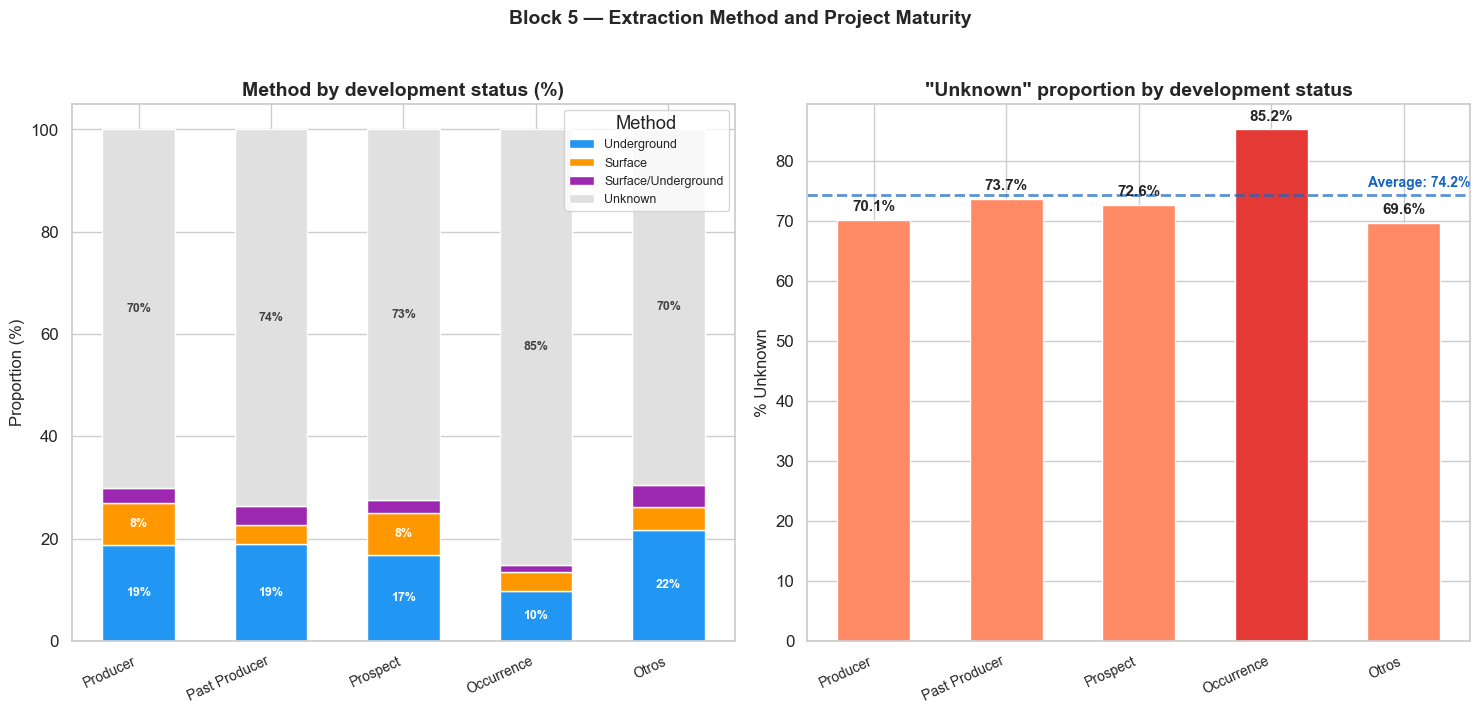

In [20]:
# BLOCK 5.2 — Dual panel: Stacked bar + Unknown bar

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# --- Left panel: 100% stacked bar by development status ---
dev_states = [d for d in DEV_ORDER if d in ct_dev.index]
x_pos = np.arange(len(dev_states))

left = np.zeros(len(dev_states))
for method in ct_dev_cols:
    values = [ct_dev.loc[d, method] if d in ct_dev.index else 0 for d in dev_states]
    color = METHOD_COLORS.get(method, "#999999")
    bars = axes[0].bar(
        x_pos,
        values,
        0.55,
        bottom=left,
        label=method,
        color=color,
        edgecolor="white",
    )
    for j, (val, l_val) in enumerate(zip(values, left)):
        if val > 6:
            axes[0].text(
                x_pos[j],
                l_val + val / 2,
                f"{val:.0f}%",
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold",
                color="white" if method != "Unknown" else "#424242",
            )
    left += np.array(values)

axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(dev_states, rotation=25, ha="right", fontsize=10)
axes[0].set_ylabel("Proportion (%)")
axes[0].set_ylim(0, 105)
axes[0].set_title("Method by development status (%)", fontweight="bold")
axes[0].legend(title="Method", loc="upper right", frameon=True, fontsize=9)

# --- Right panel: Bar chart showing only % Unknown ---
unknown_vals = [
    ct_dev.loc[d, "Unknown"] if d in ct_dev.index and "Unknown" in ct_dev.columns else 0
    for d in dev_states
]
avg_unknown = np.mean(unknown_vals)

bar_colors = ["#E53935" if v > avg_unknown else "#FF8A65" for v in unknown_vals]
bars = axes[1].bar(x_pos, unknown_vals, 0.55, color=bar_colors, edgecolor="white")

# Bar labels
for bar, val in zip(bars, unknown_vals):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{val:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

# Reference line: overall average
axes[1].axhline(y=avg_unknown, color="#1565C0", linestyle="--", linewidth=2, alpha=0.7)
axes[1].text(
    len(dev_states) - 0.5,
    avg_unknown + 1.5,
    f"Average: {avg_unknown:.1f}%",
    fontsize=10,
    color="#1565C0",
    fontweight="bold",
    ha="right",
)

axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(dev_states, rotation=25, ha="right", fontsize=10)
axes[1].set_ylabel("% Unknown")
axes[1].set_title('"Unknown" proportion by development status', fontweight="bold")

fig.suptitle(
    "Block 5 — Extraction Method and Project Maturity",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

### Insight — Block 5: Method and Project Maturity

**Key findings:**

1. **Project maturity reduces ambiguity:** Projects in "Producer" status have the **lowest proportion of "Unknown"**, confirming that operational maturity translates to greater technical precision in records.

2. **Occurrences have the highest ambiguity:** Sites classified as "Occurrence" (discoveries or evidence of mineralization without development) show the highest proportion of "Unknown" — which is logical, since at this stage the extraction method has not yet been defined.

3. **Prospects** show an intermediate level, consistent with their evaluation status: viability is being investigated but a definitive decision on the method has not yet been made.

4. **Past Producers** have low ambiguity, similar to Producers: historical operations already defined their method during their operational life.

**Partial conclusion:** The proportion of "Unknown" functions as a **proxy for the project's technical maturity**. This finding is important for data quality: information is not missing at random, but rather reflects the actual development status — prospects and occurrences naturally lack technical definition of the extraction method.

---

---

## Discussion — Integration of the 5 Analytical Blocks

The 5 analytical blocks converge into an integrated view of the territorial patterns of mining extraction methods in Peru:

### Summary of Findings

| Block | Main Finding | Implication |
|--------|-------------------|-------------|
| **B1** Diagnosis | High proportion of Unknown | The information gap is systemic but explainable |
| **B2** Mineral | Mineral conditions the method | Geology → Method (veins=Underground, porphyry=Surface) |
| **B3** Territorial | Clear regional clusters | Central Andes=Underground, Southern Andes=Surface |
| **B4** Scale | Surface → Large, Underground → Small/Medium | Economies of scale determine method viability |
| **B5** Maturity | Producers = less ambiguity | Unknown reflects technical maturity, not just missing data |

### Emerging Conceptual Model

```
Deposit geology → Mineral type → Extraction method → Production scale
                    ↕
         Territorial location (metallogenic belt)
                    ↕
         Project maturity → Record precision
```

This model suggests that the extraction method is not an independent variable, but the result of a chain of geological, geographic, and economic factors.

---

## Conclusions

### Answer to the Main Question

**What extraction method dominates in Peru by mineral type and region, and how does it relate to production scale and project development status?**

1. **Dominant method:** Underground mining is the predominant method among sites with a registered method, reflecting Peru's Andean mining tradition centered on polymetallic veins. However, a significant information gap must be considered.

2. **Mineral conditions the method:** There is a clear geological relationship — vein minerals (Zn, Pb, Ag, Au) are associated with Underground, while Copper (Cu) is associated with Surface, consistent with porphyry deposits.

3. **Robust territorial patterns:** The central Andes (Junín, Pasco, Ancash) are predominantly underground, while the southern Andes (Arequipa, Cusco, Apurímac) show greater method diversification, including more open-pit operations.

4. **Production scale matters:** Surface operations tend to be larger scale (economies of scale), while Underground is associated with small and medium operations (greater selectivity).

5. **Maturity reduces ambiguity:** Producers have a defined method; Occurrences and Prospects have a higher proportion of Unknown, reflecting their evaluation status — not simply missing data.

---

### Project Value Added

| Dimension | Contribution |
|-----------|--------|
| **Geological** | Connects mineral type and deposit geology with extraction technique |
| **Territorial** | Identifies regional clusters and metallogenic belts |
| **Economic** | Relates production scale with method viability |
| **Informational** | Transforms the "data gap" into a finding about operational maturity |
| **Methodological** | Analysis in 5 blocks with clean subsets + complete dataset |

---

### Limitations

- **High proportion of Unknown (~77%):** Although explained by project maturity, it limits the statistical power of cross-analyses.
- **Simplified primary mineral:** Only the first mineral from `commod1` was taken, losing information about polymetallic combinations.
- **No temporal data:** The dataset does not include dates, limiting trend analysis.
- **Low-granularity production scale:** The original codes (U/S/M/Y/L/N) have a high proportion of "Desconocido" (Unknown).

---